<a href="https://colab.research.google.com/github/fandri-indranata/data-science-2026/blob/main/Pertemuan11_FandriIndranata_230401010180.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama: Fandri Indranata
NIM: 230401010180
Kelas: IF401

=== Informasi Dataset ===
Shape: (333, 7)

=== Statistik Deskriptif ===
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


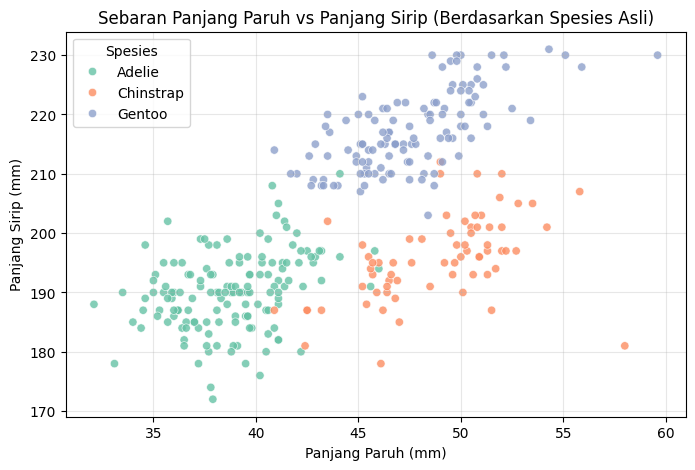

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Muat dataset penguins bawaan Seaborn
df = sns.load_dataset('penguins')

# 2. Hapus baris yang memiliki missing values
df = df.dropna()

print("=== Informasi Dataset ===")
print(f"Shape: {df.shape}")
print("\n=== Statistik Deskriptif ===")
print(df.describe().round(2))

# 3. Eksplorasi awal: Scatter plot berdasarkan spesies asli (sebagai ground truth)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm',
                hue='species', palette='Set2', alpha=0.8)
plt.title('Sebaran Panjang Paruh vs Panjang Sirip (Berdasarkan Spesies Asli)')
plt.xlabel('Panjang Paruh (mm)')
plt.ylabel('Panjang Sirip (mm)')
plt.legend(title='Spesies')
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
from sklearn.preprocessing import StandardScaler

# Pilih hanya fitur numerik yang relevan untuk clustering
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[features].values

# Terapkan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling:", X_scaled.mean(axis=0).round(3))
print("Std setelah scaling :", X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [ 0.  0.  0. -0.]
Std setelah scaling : [1. 1. 1. 1.]


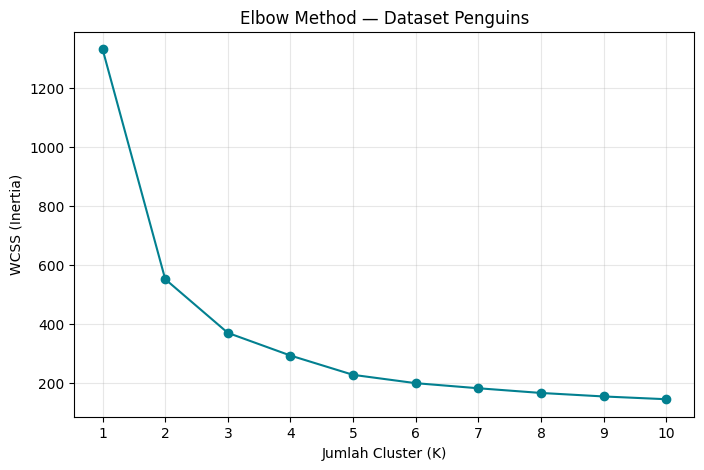

In [3]:
from sklearn.cluster import KMeans

wcss = []
# n_init=10 ditambahkan untuk menghindari warning di versi scikit-learn terbaru
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#028090', linestyle='-')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method — Dataset Penguins')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
from sklearn.metrics import silhouette_score

# Latih model dengan K=3
optimal_k = 3
model = KMeans(n_clusters=optimal_k, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)

# Tambahkan label cluster ke dataframe asli
df['cluster'] = model.labels_

print(f"WCSS akhir (Inertia): {model.inertia_:.3f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}")

print("\n=== Rata-rata Fitur per Cluster ===")
# Urutkan berdasarkan body_mass_g agar interpretasi lebih mudah
print(df.groupby('cluster')[features].mean().round(2).sort_values(by='body_mass_g'))

WCSS akhir (Inertia): 370.766
Silhouette Score: 0.446

=== Rata-rata Fitur per Cluster ===
         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
cluster                                                               
0                 38.28          18.12             188.63      3593.80
2                 47.66          18.75             196.92      3898.24
1                 47.57          15.00             217.24      5092.44


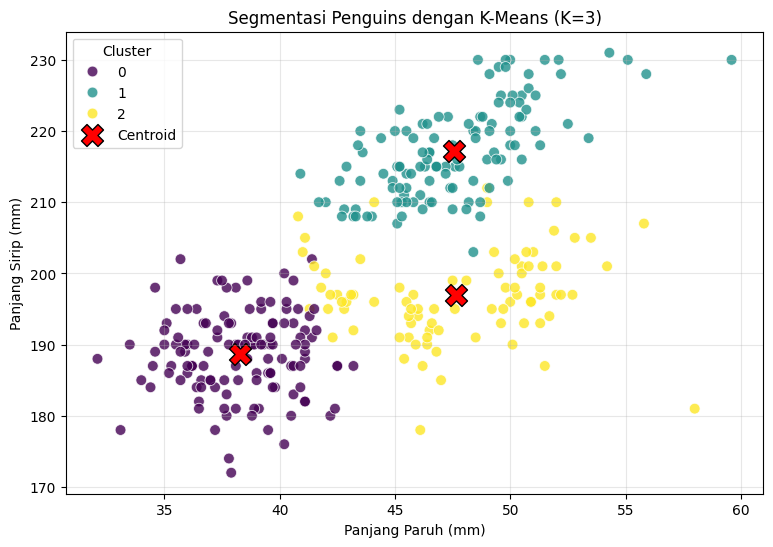

In [5]:
# Kembalikan nilai centroid ke skala asli agar sumbu grafik mudah dibaca
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(9, 6))

# Scatter plot data berdasarkan cluster hasil K-Means
sns.scatterplot(x=df['bill_length_mm'], y=df['flipper_length_mm'],
                hue=df['cluster'], palette='viridis', alpha=0.8, s=60)

# Plot posisi centroid (Indeks 0 = bill_length, Indeks 2 = flipper_length)
plt.scatter(centroids[:, 0], centroids[:, 2],
            c='red', marker='X', s=250, edgecolor='black', label='Centroid')

plt.xlabel('Panjang Paruh (mm)')
plt.ylabel('Panjang Sirip (mm)')
plt.title('Segmentasi Penguins dengan K-Means (K=3)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

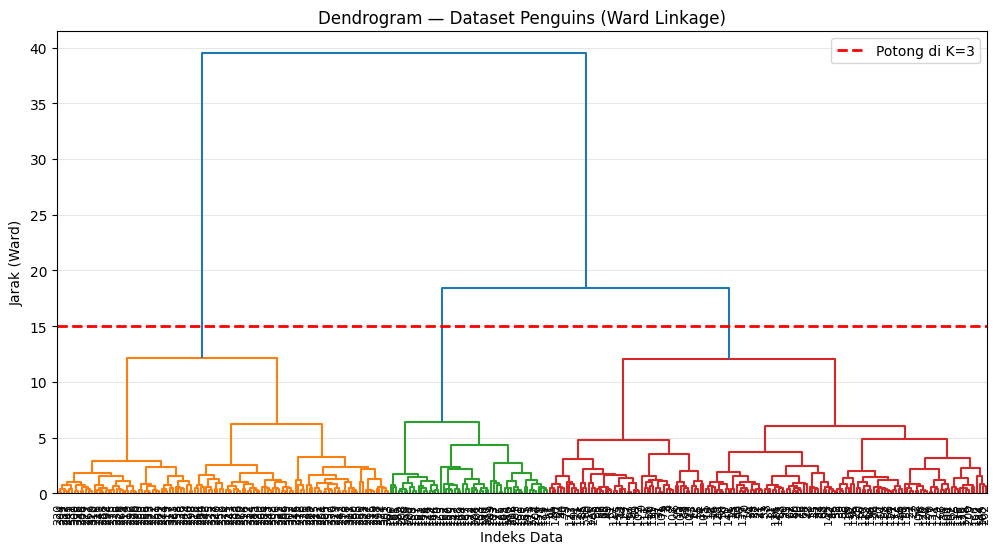

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Hitung linkage menggunakan metode Ward (meminimalkan varians dalam cluster)
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8, color_threshold=15)
plt.title('Dendrogram — Dataset Penguins (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')

# Garis potong horizontal untuk menunjukkan K=3
plt.axhline(y=15, color='red', linestyle='--', linewidth=2, label='Potong di K=3')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()